## 12 - Heatmaps & 2D Plots

### What is a Heatmap?
A **heatmap** encodes numeric values as **colours in a grid**. Dark or bright colours show high values; light or neutral colours show low values. It is perfect for showing relationships between two categorical dimensions.

### When to use a Heatmap
✅ Correlation matrix - how correlated are different subjects?
✅ Confusion matrix - in machine learning
✅ City × Subject average scores grid
✅ Any table where colour helps read values faster

### plt.imshow() - the heatmap function
```python
plt.imshow(matrix,              # 2D array of values
           cmap='coolwarm',     # colormap
           vmin=-1, vmax=1)     # value range for color scale
plt.colorbar(label='...')       # add the color scale bar
```

### Adding text inside heatmap cells
```python
for i in range(rows):
    for j in range(cols):
        plt.text(j, i, f'{matrix[i,j]:.2f}',
                 ha='center', va='center',
                 color='white' if abs(matrix[i,j]) > 0.5 else 'black')
```

### Colormaps for heatmaps
| Colormap | Best for |
|----------|----------|
| `'coolwarm'` | Diverging - negative (blue) to positive (red) - correlation |
| `'RdYlGn'` | Red (bad) → Yellow (mid) → Green (good) |
| `'Blues'` | Light to dark blue - sequential |
| `'viridis'` | Perceptually uniform - good general default |
| `'YlOrRd'` | Yellow → Orange → Red (intensity) |


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
rng  = np.random.default_rng(42)
n    = 50
study = rng.uniform(3, 15, n)
maths   = (study*4   + rng.normal(25, 8, n)).clip(0, 100)
science = (study*3.5 + rng.normal(28, 9, n)).clip(0, 100)
english = (study*3   + rng.normal(36, 8, n)).clip(0, 100)
compsci = (study*3.8 + rng.normal(28, 8, n)).clip(0, 100)
attend  = (study*2.5 + rng.normal(55, 8, n)).clip(40, 100)

In [3]:
df = pd.DataFrame({'maths':maths,'science':science,
                   'english':english,'compSci':compsci,
                   'study_hours':study,'attendance':attend})

corr = df.corr().round(2)
labels = corr.columns.tolist()

### Plot 1 : Correlation matrix heatmap

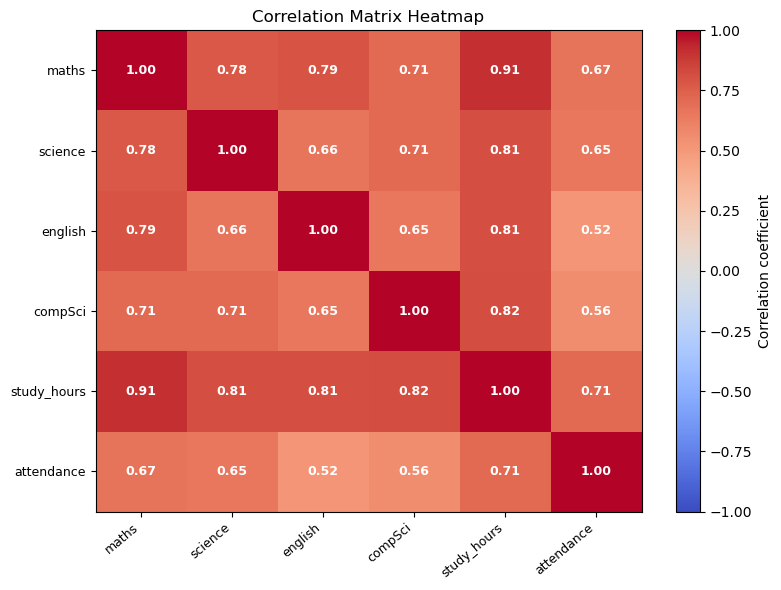

In [7]:
plt.figure(figsize=(8, 6))
im = plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, label='Correlation coefficient')

plt.xticks(range(len(labels)), labels, rotation=40, ha='right', fontsize=9)
plt.yticks(range(len(labels)), labels, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        val   = corr.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        plt.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=9, color=color, fontweight='bold')

plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

### Plot 2 : City × Subject pivot heatmap

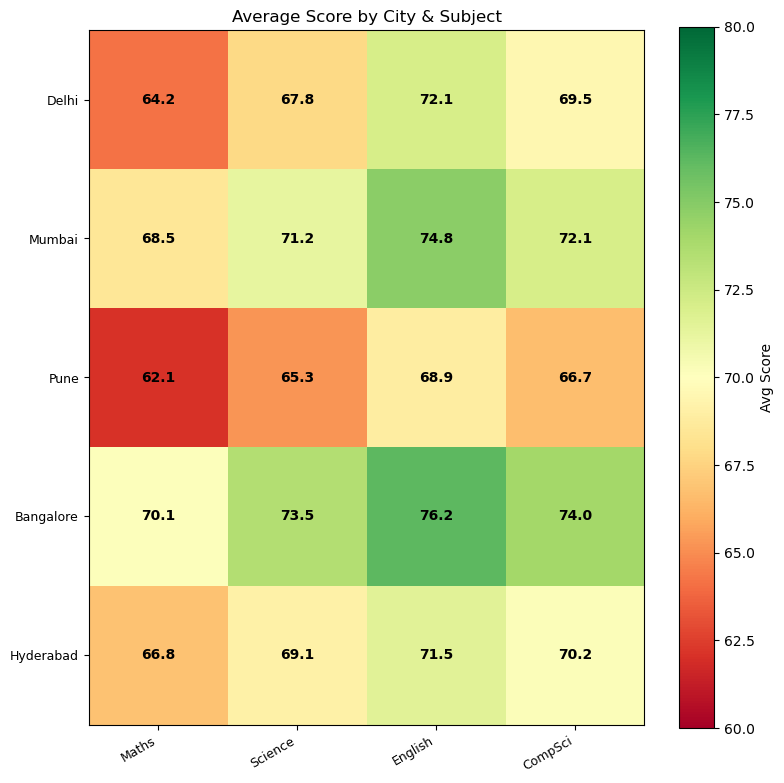

In [11]:
cities   = ['Delhi', 'Mumbai', 'Pune', 'Bangalore', 'Hyderabad']
subjects = ['Maths', 'Science', 'English', 'CompSci']
pivot = np.array([
    [64.2, 67.8, 72.1, 69.5],
    [68.5, 71.2, 74.8, 72.1],
    [62.1, 65.3, 68.9, 66.7],
    [70.1, 73.5, 76.2, 74.0],
    [66.8, 69.1, 71.5, 70.2],
])

plt.figure(figsize=(8, 8))
im2 = plt.imshow(pivot, cmap='RdYlGn', vmin=60, vmax=80)
plt.colorbar(im2, label='Avg Score')

plt.xticks(range(len(subjects)), subjects, rotation=30, ha='right', fontsize=9)
plt.yticks(range(len(cities)), cities, fontsize=9)

for i in range(len(cities)):
    for j in range(len(subjects)):
        plt.text(j, i, f'{pivot[i,j]:.1f}', ha='center', va='center',
                 fontsize=10, fontweight='bold', color='black')

plt.title('Average Score by City & Subject')
plt.tight_layout()
plt.show()

### Plot 3 : 2D Histogram (hexbin) 

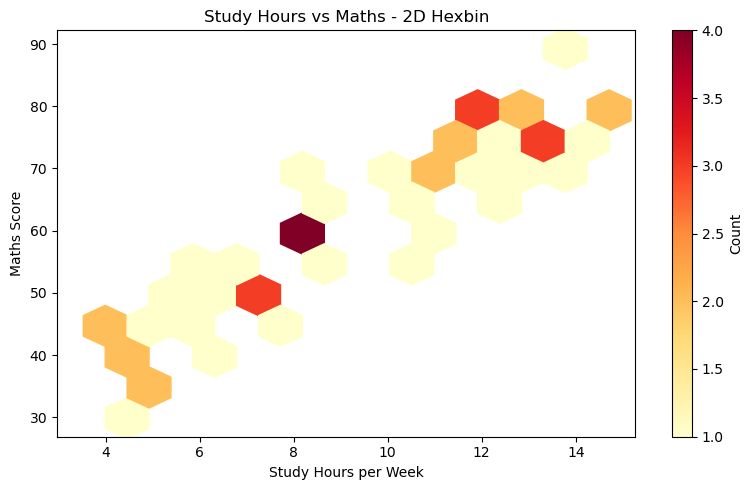

In [13]:
plt.figure(figsize=(8, 5))

hb = plt.hexbin(study, maths, gridsize=12, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, label='Count')

plt.title('Study Hours vs Maths - 2D Hexbin')
plt.xlabel('Study Hours per Week')
plt.ylabel('Maths Score')

plt.tight_layout()
plt.show()